Shape before: (10494, 57)
Shape after: (10494, 7)
Remaining coluumns: Index(['year', 'season', 'is_commercial_rte', 'max_elev_reached', 'total_mbrs',
       'mbrs_summited', 'is_o2_climbing'],
      dtype='object')


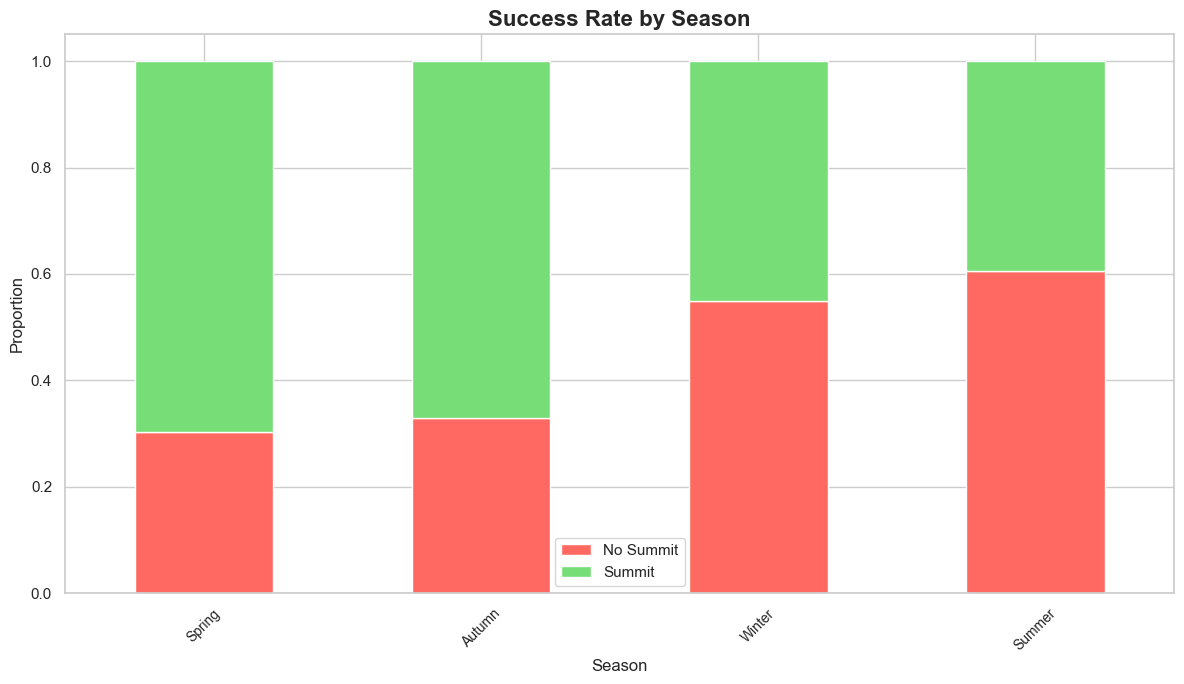

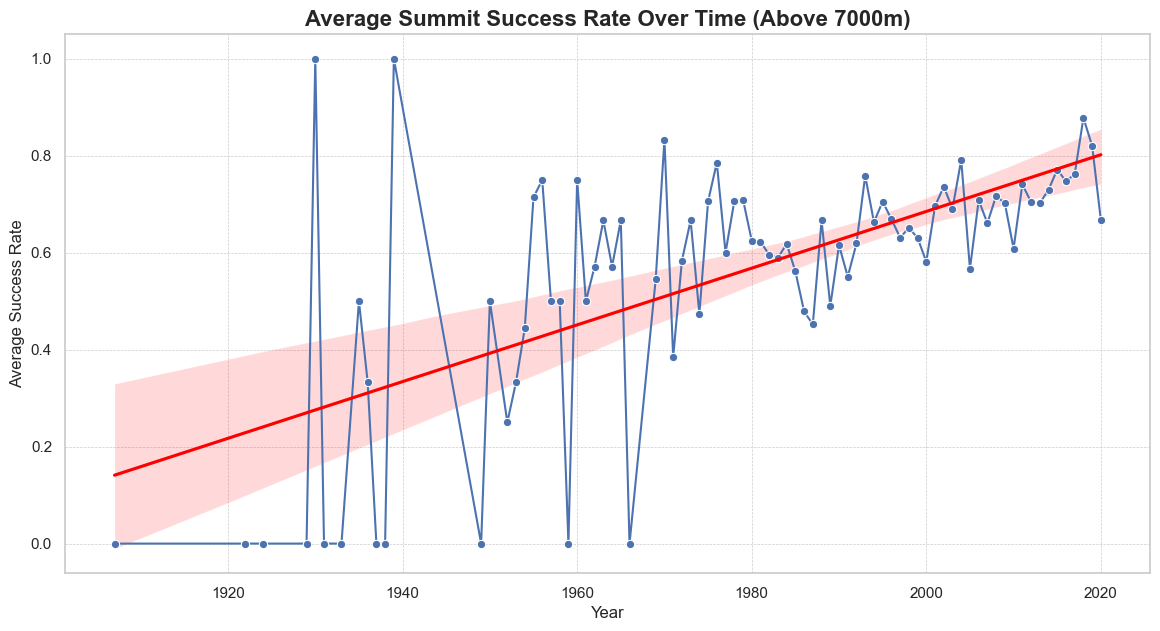

      is_commercial_rte  total_mbrs  is_o2_climbing  success  season_Autumn  \
1443                  0           8               0        1          False   
1447                  0           9               0        0          False   
1448                  0          17               1        1          False   
1449                  0          12               1        1          False   
1451                  0          11               0        0          False   

      season_Spring  season_Summer  season_Winter  
1443           True          False          False  
1447           True          False          False  
1448           True          False          False  
1449           True          False          False  
1451           True          False          False  

ANOVA F-test Feature Ranking
             Feature     F-Score        P-Value
2     is_o2_climbing  479.879410  2.324551e-102
1         total_mbrs   81.138435   2.787796e-19
6      season_Winter   29.934518   4.65

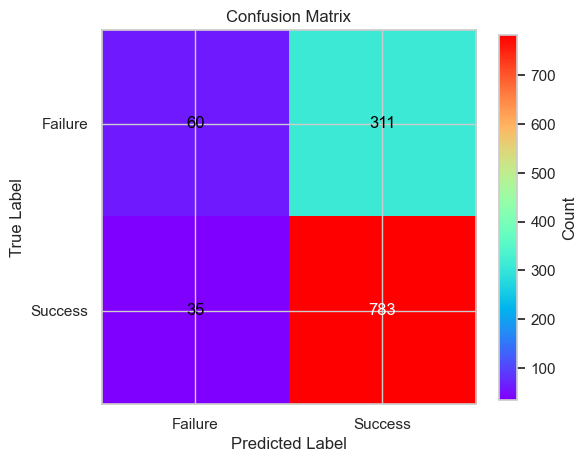

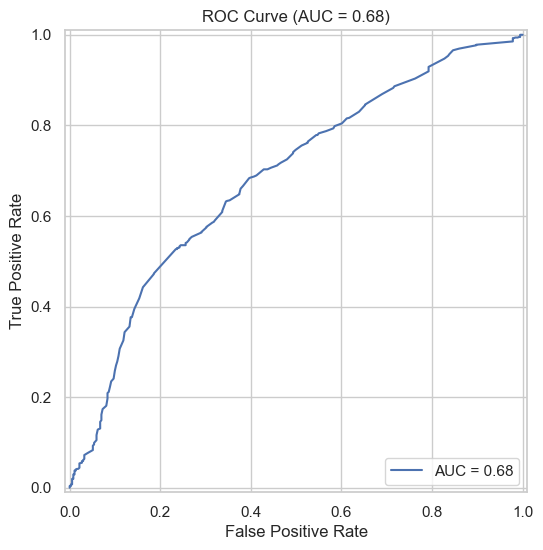



--- End of EDA and First Model. Begin GLM ---


                 Generalized Linear Model Regression Results                  
Dep. Variable:                success   No. Observations:                 5945
Model:                            GLM   Df Residuals:                     5938
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3443.5
Date:                Wed, 18 Jun 2025   Deviance:                       6886.9
Time:                        16:10:45   Pearson chi2:                 6.06e+03
No. Iterations:                    24   Pseudo R-squ. (CS):            0.09081
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc, RocCurveDisplay
import statsmodels.api as sm
import statsmodels.formula.api as smf


# Set up plotting style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

bpath = 'overleaf'

def rank_features(X, y):
    """Rank features using ANOVA F-test."""
    f_scores, p_values = f_classif(X, y)
    feature_ranking = pd.DataFrame({
        'Feature': X.columns,
        'F-Score': f_scores,
        'P-Value': p_values
    }).sort_values(by='F-Score', ascending=False)
    print("\nANOVA F-test Feature Ranking")
    return feature_ranking


def plot_success_rate_year(df):
  # Analyzing a Numerical Feature: Year
  # How have success rates changed over time?
  plt.figure(figsize=(14, 7))
  # Calculate success rate per year
  yearly_success = df_eda.groupby('year')['success'].mean()
  sns.lineplot(x=yearly_success.index, y=yearly_success.values, marker='o')
  sns.regplot(x=yearly_success.index, y=yearly_success.values, scatter=False, color='red')
  title = 'Average Summit Success Rate Over Time (Above 7000m)'
  plt.title(title, fontsize=16, weight='bold')
  plt.xlabel('Year', fontsize=12)
  plt.ylabel('Average Success Rate', fontsize=12)
  plt.grid(True, linestyle='--', linewidth=0.5)
  # save to google drive
  plt.savefig(f'{bpath}/{title}.png', dpi=300, format='png', bbox_inches='tight')
  plt.show()


def plot_success_rate(df, column, title):
    """
    Helper function to calculate and plot success rates for a given column.
    """
    # Calculate success rate for each category in the column
    success_rate = df.groupby(column)['success'].value_counts(normalize=True).unstack()
    success_rate = success_rate.sort_values(by=1, ascending=False) # Sort by success rate (1)

    # Plotting
    _, ax = plt.subplots(figsize=(12, 7))
    success_rate.plot(kind='bar', stacked=True, ax=ax, color=['#ff6961', '#77dd77'])

    # Formatting
    ax.set_title(title, fontsize=16, weight='bold')
    ax.set_xlabel(column.replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)
    ax.legend(['No Summit', 'Summit'])
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    plt.tight_layout()
    # save to google drive
    plt.savefig(f'{bpath}/{title}.png', dpi=300, format='png', bbox_inches='tight')
    plt.show()


def plot_coorelation_matrix(df):
  # Correlation Matrix for Numeric/Boolean Features
  # Let's see how our initial features and some others correlate with success
  numeric_cols = [
       'summitted',
       'is_o2_used',
       'season_Autumn',
       'season_Spring',
       'season_Summer',
       'season_Winter'
  ]

  print(df_eda[numeric_cols].head())
  corr_matrix = df_eda[numeric_cols].corr()

  plt.figure(figsize=(10, 8))
  sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
  plt.title('Correlation Matrix of Key Features', fontsize=16, weight='bold')
  plt.savefig(f'{bpath}/Correlation_Matrix_of_Key_Features.png', dpi=300, format='png', bbox_inches='tight')



def train_and_evaluate_model(X, y):
    """Train and evaluate a logistic regression model."""
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test_scaled)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Calculate Peirce Skill Score (PSS)
    # Also known as True Positive Rate - False Positive Rate
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) # This is the same as Recall
    fpr = fp / (fp + tn)
    pss = tpr - fpr
    print(f"Peirce Skill Score (PSS): {pss:.2f}")

    # Calculate Heidke Skill Score (HSS)
    numerator = 2 * (tp * tn - fp * fn)
    denominator = (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)
    hss = numerator / denominator

    print(f"Heidke Skill Score (HSS): {hss:.2f}")

    plt.figure(figsize=(6, 6))
    plt.imshow(cm, cmap='rainbow')
    plt.colorbar(label='Count', shrink=0.65)
    plt.xticks([0, 1], ['Failure', 'Success'])
    plt.yticks([0, 1], ['Failure', 'Success'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title("Confusion Matrix")

    # Add text annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f'{cm[i, j]}', ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')

    plt.tight_layout()
    plt.savefig(f'{bpath}/Confusion_Matrix.png', dpi=300, format='png', bbox_inches='tight')
    plt.show()

    # ROC Curve
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
    plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.savefig(f'{bpath}/ROC_Curve.png', dpi=300, format='png', bbox_inches='tight')
    plt.show()


# Initial list of features that has nothing to with influencing success
bad_features = ['peak_id', 'peak_name', 'nationality',
                'host_cntr', 'other_cntrs', 'sponsor', 'leaders',
                'team_asc_1', 'team_asc_2', 'team_asc_3', 'team_asc_4',
                'is_disputed', 'is_claim',
                'is_standard_rte', 'other_smts', 'approach', 'bc_arrived',
                'bc_left', 'total_days', 'is_traverse', 'is_ski_snowboard',
                'is_parapente', 'term_note', 'summit_day', 'time',
                'summit_days', 'mbrs_deaths', 'high_camps',
                'hired_abc', 'hired_summits', 'hired_deaths', 'rope_fixed',
                'is_no_hired_abc', 'is_o2_not_used', 'is_o2_used',
                'is_o2_descent', 'is_o2_sleeping', 'is_o2_medical',
                'is_o2_unkwn', 'had_o2', 'camp_sites', 'accidents',
                'achievements', 'agency', 'members', 'rte_2_name',
                'rte_3_name', 'rte_4_name', 'rte_1_name', 'exp_result']


# Load the dataset
#df = get_data()
df = pd.read_csv('data/expeditions.csv')
#print(df.columns)

# --- Exploratory Data Analysis (EDA) ---

# remove unwanted columns
# print shape before and after
print(f"Shape before: {df.shape}")
df.drop(columns=bad_features, inplace=True)
print(f"Shape after: {df.shape}")
print(f'Remaining coluumns: {df.columns}')

# Filter for expeditions above 7000 meters
df_eda = df[df['max_elev_reached'] > 7000].copy()
# remove 'max_elev_reached'
df_eda = df_eda.drop(columns=['max_elev_reached'])
# transform mbrs_summitted to binary
df_eda['success'] = (df_eda['mbrs_summited'] > 0).astype(int)
df_eda = df_eda.drop(columns=['mbrs_summited'])
# # convert exp_result to binary
# df_eda['exp_result'] = (df_eda['exp_result'] == 'Success').astype(int)
# # rename exp_result to success
# df_eda = df_eda.rename(columns={'exp_result': 'success'})
# # remove where sumitted and success are not equal
# df_eda = df_eda[df_eda['summitted'] == df_eda['success']]

# Analyzing Key Categorical Features
# How does success vary by season?
plot_success_rate(df_eda, 'season', 'Success Rate by Season')
plot_success_rate_year(df_eda)

# remove summitted
# df_eda = df_eda.drop(columns=['summitted'])

# Analyzing a Numerical Feature: Year
# remove year
df_eda = df_eda.drop(columns=['year'])
# One-hot on seasons
df_eda = pd.get_dummies(df_eda, columns=['season'])

print(df_eda.head())
# plot_coorelation_matrix(df_eda)

# Drop rows with NaNs
df_eda.dropna(inplace=True)
# split into target and features
y = df_eda['success']
X = df_eda.drop(columns=['success'])
# rank features
feature_ranking = rank_features(X, y)
print(feature_ranking)

# Train and evaluate model
train_and_evaluate_model(X, y)


print('\n\n--- End of EDA and First Model. Begin GLM ---\n\n')


# Model Definition and Fitting ---
# This is highly readable: "summited is predicted by season, oxygen use, and standard route"
# C(season) tells statsmodels to treat 'season' as a categorical variable.
formula = "success ~ C(season_Autumn) + C(season_Spring) + C(season_Summer) + C(season_Winter) + C(is_o2_climbing) + C(is_commercial_rte) + total_mbrs"

# Create and fit the Generalized Linear Model (GLM) with a Logit link function.
# This is equivalent to logistic regression.
# The `family=sm.families.Binomial()` specifies that our outcome is binary.
logit_model = smf.glm(formula=formula, data=df_eda, family=sm.families.Binomial()).fit()


# Model Summary and Interpretation

# Print the detailed statistical summary of the model
print(logit_model.summary())

# --- Odds Ratios ---
# Extract confidence intervals as separate Series
conf_int = logit_model.conf_int()
lower_bound = conf_int[0]  # Lower bound (2.5%)
upper_bound = conf_int[1]  # Upper bound (97.5%)

# Create odds ratios DataFrame
odds_ratios = pd.DataFrame(
    {
        "Odds Ratio": np.exp(logit_model.params),
        "2.5%": np.exp(lower_bound),
        "97.5%": np.exp(upper_bound),
    }
)
print(odds_ratios)

# --- Interpretation Notes for Odds Ratios ---
#
# 1. Odds Ratio > 1: The odds of summiting increase when this predictor is present or increases.
# 2. Odds Ratio < 1: The odds of summiting decrease when this predictor is present or increases.
# 3. Odds Ratio = 1: The predictor has no effect on the odds of summiting.
#
# For example, if the odds ratio for 'is_o2_climbing' is 2.5, it means
# the odds of a successful summit are 2.5 times higher for expeditions that use
# oxygen while climbing compared to those that do not, holding other factors constant.